In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn pymongo


Note: you may need to restart the kernel to use updated packages.


# 📊 Análisis de Correlación y Separabilidad - fact_competencia

## Objetivo:
1. Cargar datos desde MongoDB
2. Calcular matriz de correlación
3. Identificar features redundantes (correlación > 0.9)
4. Visualizar en t-SNE 2D para ver separabilidad de clases
5. Recomendaciones de reducción de características

## PASO 1: Importar Librerías y Cargar Datos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.manifold import TSNE
import pymongo
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [3]:
# Conectar a MongoDB y cargar datos
try:
    client = pymongo.MongoClient("mongodb://localhost:27017/")
    db = client["ProyectoBueno"]
    collection = db["fact_competencia"]
    data = list(collection.find())
    print(f"✅ Conexión exitosa. Registros cargados: {len(data)}")
except Exception as e:
    print(f"❌ Error: {e}")
    print("Asegúrate de que MongoDB esté corriendo")

✅ Conexión exitosa. Registros cargados: 1200


In [4]:
# Aplanar registros recursivamente
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df_raw = pd.DataFrame(flat_data)
print(f"\n📊 Dimensiones iniciales: {df_raw.shape}")
print(f"\nPrimeras filas:")
df_raw.head(2)


📊 Dimensiones iniciales: (1200, 41)

Primeras filas:


,_id,id_competencia,id_tiempo,id_producto,id_competidor,region,precio_nuestro,precio_competidor,diferencia_precio,pct_diferencia,...,producto_precio_costo,producto_precio_venta,producto_margen_ganancia,producto_stock_minimo,producto_origen,producto_estado,producto_anio_ingreso,competidor_id_competidor,competidor_nombre_competidor,_collection
0,50e84b97-46af-4464-8610-66e9919ebc4d,1,139,483,7,Insular,29.20,26.26,2.94,0.1120,...,19.34,29.20,0.51,12,NACIONAL,ACTIVO,2021,7,MEGAMAXI,fact_competencia
1,ea104a11-3cf2-4eb4-9e08-190fa4eac797,2,44,963,2,Insular,22.15,22.45,-0.30,-0.0134,...,14.67,22.15,0.51,41,NACIONAL,ACTIVO,2024,2,TIA,fact_competencia


## PASO 2: Preprocesamiento Básico

In [5]:
# Crear target (igual a los notebooks originales)
# fact_competencia: Predicción de competitividad (asumimos 3 clases)
# Detectar automáticamente qué columnas pueden ser el target

# Mostrar tipos de datos
print("Tipos de datos y columnas:")
print(df_raw.dtypes)
print(f"\nColumnas únicas: {df_raw.columns.tolist()[:20]}...") 

Tipos de datos y columnas:
_id                                    str
id_competencia                       int64
id_tiempo                            int64
id_producto                          int64
id_competidor                        int64
region                                 str
precio_nuestro                     float64
precio_competidor                  float64
diferencia_precio                  float64
pct_diferencia                     float64
tiempo_id_tiempo                     int64
tiempo_fecha                           str
tiempo_hora                            str
tiempo_anio                          int64
tiempo_semestre                      int64
tiempo_trimestre                     int64
tiempo_mes                           int64
tiempo_nombre_mes                      str
tiempo_semana_anio                   int64
tiempo_dia_mes                       int64
tiempo_dia_semana                      str
tiempo_es_fin_semana                 int64
tiempo_es_feriado          

In [6]:
# Copiar para procesamiento
df = df_raw.copy()

# IMPORTANTE: Necesitas especificar cómo se calcula el target para fact_competencia
# Por ahora, si existe "target" o "clase" o "competitividad", usamos eso
# Si no, creamos uno dummy para el análisis

target_col = None
for col in df.columns:
    if 'target' in col.lower() or 'class' in col.lower() or 'competitiv' in col.lower() or 'categoria' in col.lower():
        target_col = col
        print(f"✅ Target detectado: {target_col}")
        break

if target_col is None:
    print("⚠️ No se detectó columna target. Verifica manualmente cuál usar.")
    print(f"\nÚltimas columnas: {df.columns.tolist()[-10:]}")
    # Por ahora, mostramos todas las columnas numéricas y categóricas
    print(f"\nValores únicos en columnas clave:")
    for col in df.columns[-5:]:
        if df[col].nunique() < 20:
            print(f"  {col}: {df[col].nunique()} valores únicos")

✅ Target detectado: producto_categoria


In [7]:
# Limpiar datos: eliminar IDs, fechas, textos
cols_to_drop = []
for col in df.columns:
    # Eliminar IDs, ObjectIds, emails, etc.
    if any(x in col.lower() for x in ['_id', 'id', 'email', 'name', 'fecha', 'date', 'codigo', 'nombre', 'correo', 'telefono', 'hora', 'collection']):
        cols_to_drop.append(col)
        
df_clean = df.drop(columns=cols_to_drop)
print(f"✅ Columnas eliminadas (IDs, texto): {len(cols_to_drop)}")
print(f"📊 Dimensiones después de limpieza: {df_clean.shape}")
print(f"\nColumnas restantes: {df_clean.columns.tolist()[:20]}...")

✅ Columnas eliminadas (IDs, texto): 19
📊 Dimensiones después de limpieza: (1200, 22)

Columnas restantes: ['region', 'precio_nuestro', 'diferencia_precio', 'pct_diferencia', 'tiempo_anio', 'tiempo_semestre', 'tiempo_trimestre', 'tiempo_mes', 'tiempo_semana_anio', 'tiempo_dia_mes', 'tiempo_dia_semana', 'tiempo_es_fin_semana', 'tiempo_es_feriado', 'producto_categoria', 'producto_subcategoria', 'producto_precio_costo', 'producto_precio_venta', 'producto_margen_ganancia', 'producto_stock_minimo', 'producto_origen']...


In [8]:
# Separar numéricas y categóricas
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"📊 Características Numéricas: {len(numeric_cols)}")
print(f"📊 Características Categóricas: {len(categorical_cols)}")
print(f"\nNuméricas: {numeric_cols[:10]}...")
print(f"\nCategóricas: {categorical_cols[:10]}...")

📊 Características Numéricas: 16
📊 Características Categóricas: 6

Numéricas: ['precio_nuestro', 'diferencia_precio', 'pct_diferencia', 'tiempo_anio', 'tiempo_semestre', 'tiempo_trimestre', 'tiempo_mes', 'tiempo_semana_anio', 'tiempo_dia_mes', 'tiempo_es_fin_semana']...

Categóricas: ['region', 'tiempo_dia_semana', 'producto_categoria', 'producto_subcategoria', 'producto_origen', 'producto_estado']...


In [9]:
# Imputación de nulos
for col in numeric_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in categorical_cols:
    df_clean[col].fillna(df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'UNKNOWN', inplace=True)

print(f"✅ Nulos imputados")
print(f"Nulos restantes: {df_clean.isnull().sum().sum()}")

✅ Nulos imputados
Nulos restantes: 0


In [10]:
# One-Hot Encoding de categóricas
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print(f"✅ One-Hot Encoding aplicado")
print(f"📊 Dimensiones después de encoding: {df_encoded.shape}")
print(f"\nNuevas características: {df_encoded.columns.tolist()[:10]}...")

✅ One-Hot Encoding aplicado


📊 Dimensiones después de encoding: (1200, 179)

Nuevas características: ['precio_nuestro', 'diferencia_precio', 'pct_diferencia', 'tiempo_anio', 'tiempo_semestre', 'tiempo_trimestre', 'tiempo_mes', 'tiempo_semana_anio', 'tiempo_dia_mes', 'tiempo_es_fin_semana']...


## PASO 3: Análisis de Correlación

In [11]:
# Calcular matriz de correlación
corr_matrix = df_encoded.corr()
print(f"✅ Matriz de correlación calculada: {corr_matrix.shape}")
print(f"\nCorrelación con la primera feature:")
print(corr_matrix.iloc[:, 0].sort_values(ascending=False)[:10])

✅ Matriz de correlación calculada: (179, 179)

Correlación con la primera feature:
precio_nuestro                             1.000000
producto_precio_venta                      1.000000
producto_precio_costo                      0.994533
producto_categoria_TECNOLOGIA              0.765911
producto_subcategoria_IMPRESORAS           0.363691
producto_subcategoria_TELEVISORES          0.315225
producto_subcategoria_SOFTWARE             0.251985
producto_subcategoria_COMPUTADORES         0.241290
producto_subcategoria_GAMING               0.233640
producto_subcategoria_ELECTRODOMESTICOS    0.203652
Name: precio_nuestro, dtype: float64


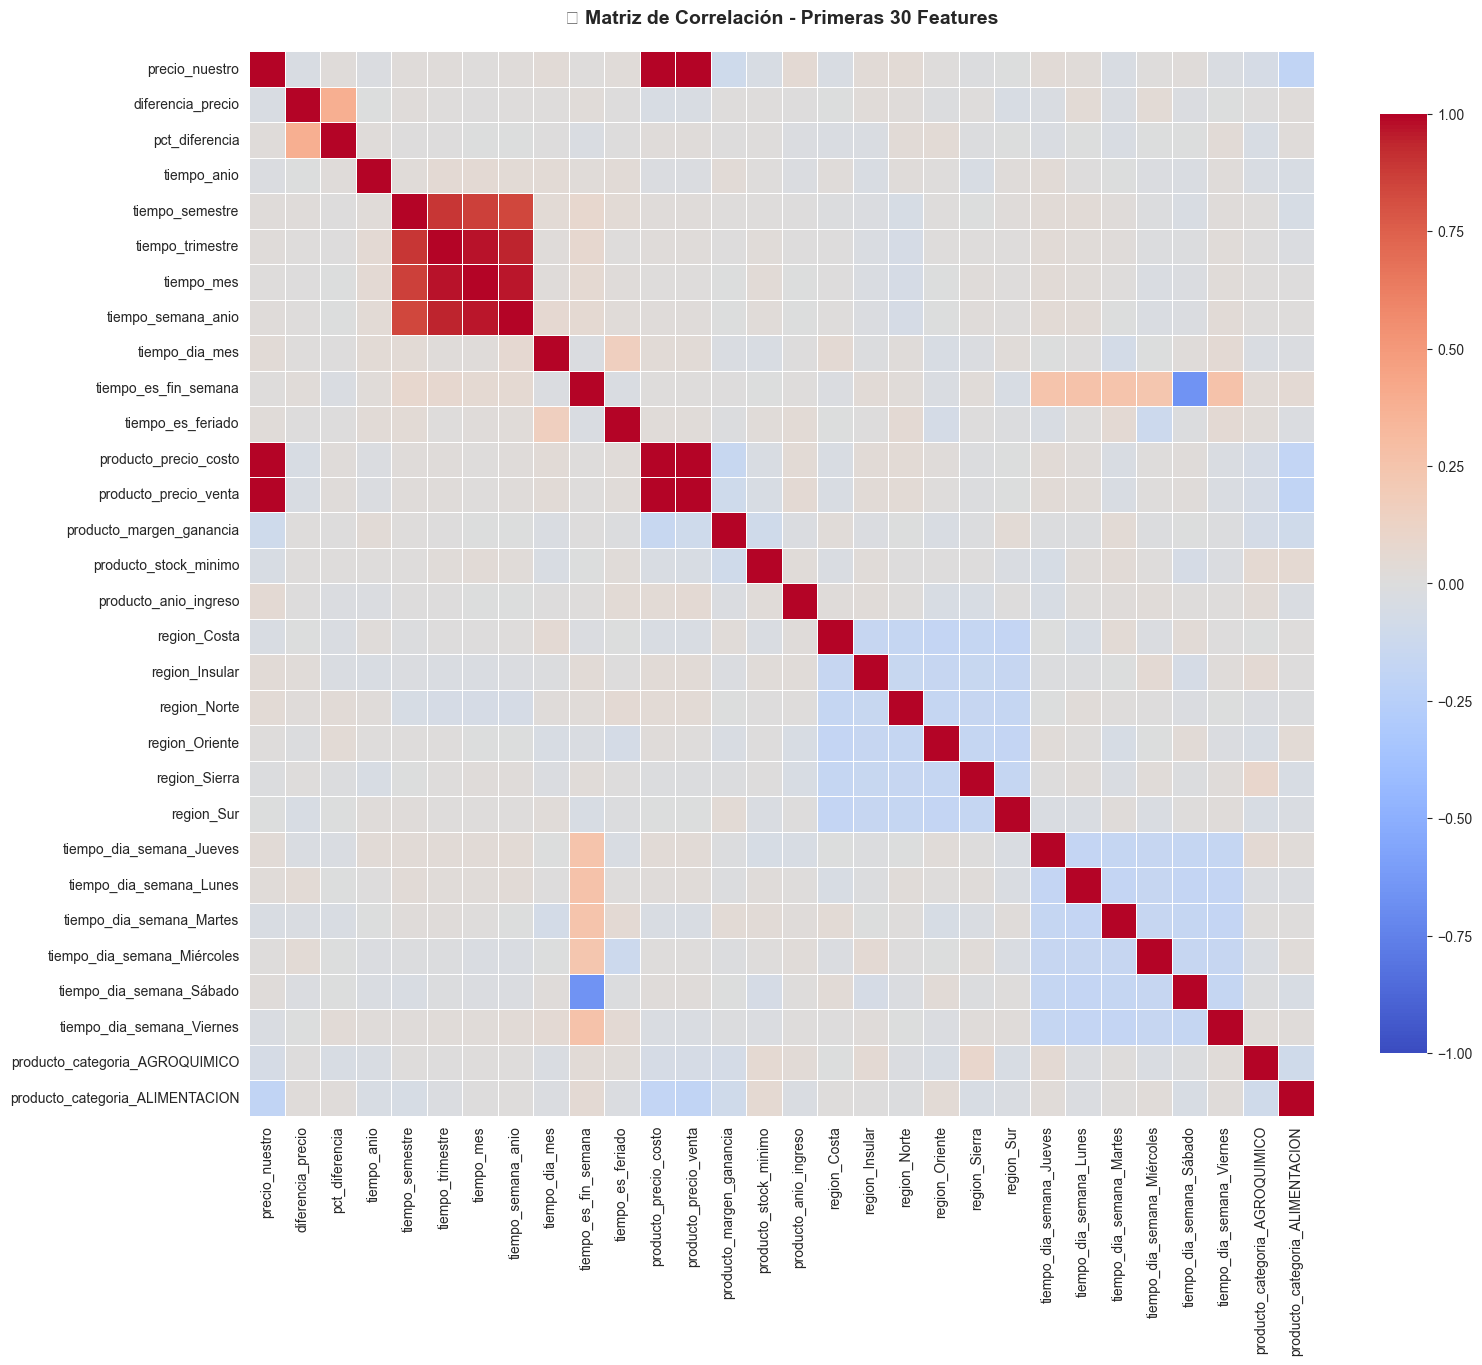

✅ Heatmap guardado en outputs/01_correlacion_heatmap.png


In [12]:
# Visualizar heatmap de correlación (primeras 30 features)
fig, ax = plt.subplots(figsize=(16, 14))

# Si hay muchas features, mostrar solo las primeras 30
n_features_display = min(30, df_encoded.shape[1])
corr_subset = corr_matrix.iloc[:n_features_display, :n_features_display]

sns.heatmap(corr_subset, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax, vmin=-1, vmax=1)

ax.set_title(f'🔥 Matriz de Correlación - Primeras {n_features_display} Features', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/01_correlacion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Heatmap guardado en outputs/01_correlacion_heatmap.png")

In [13]:
# Detectar features altamente correlacionadas (redundantes)
# Encontrar pares con correlación > 0.9

def find_highly_correlated_pairs(corr_matrix, threshold=0.9):
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                pairs.append({
                    'feature1': corr_matrix.columns[i],
                    'feature2': corr_matrix.columns[j],
                    'correlacion': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(pairs).sort_values('correlacion', ascending=False, key=abs)

highly_corr = find_highly_correlated_pairs(corr_matrix, threshold=0.9)
print(f"\n🔴 Features ALTAMENTE correlacionadas (> 0.9): {len(highly_corr)}")
if len(highly_corr) > 0:
    print("\nPrimeros 20 pares:")
    print(highly_corr.head(20).to_string())
else:
    print("No hay pares con correlación > 0.9")

# También mostrar correlaciones moderadas
mod_corr = find_highly_correlated_pairs(corr_matrix, threshold=0.7)
print(f"\n🟠 Features moderadamente correlacionadas (0.7-0.9): {len(mod_corr) - len(highly_corr)}")
print(f"Total de pares correlacionados (>0.7): {len(mod_corr)}")


🔴 Features ALTAMENTE correlacionadas (> 0.9): 7

Primeros 20 pares:
                     feature1                       feature2  correlacion
1              precio_nuestro          producto_precio_venta     1.000000
6  producto_categoria_LACTEOS  producto_subcategoria_LACTEOS     1.000000
0              precio_nuestro          producto_precio_costo     0.994533
5       producto_precio_costo          producto_precio_venta     0.994533
2            tiempo_trimestre                     tiempo_mes     0.972710
4                  tiempo_mes             tiempo_semana_anio     0.965900
3            tiempo_trimestre             tiempo_semana_anio     0.944243



🟠 Features moderadamente correlacionadas (0.7-0.9): 8
Total de pares correlacionados (>0.7): 15


In [14]:
# Estadísticas de correlación
print("\n📊 ESTADÍSTICAS DE CORRELACIÓN:")
print(f"Media de correlaciones: {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean():.4f}")
print(f"Máxima correlación (excluyendo diagonal): {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].max():.4f}")
print(f"Mínima correlación: {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].min():.4f}")

# Top 10 features más correlacionadas con otras
avg_corr_per_feature = corr_matrix.abs().mean().sort_values(ascending=False)
print(f"\n🔗 Top 10 features más correlacionadas (promedio):")
print(avg_corr_per_feature.head(10))


📊 ESTADÍSTICAS DE CORRELACIÓN:
Media de correlaciones: -0.0037
Máxima correlación (excluyendo diagonal): 1.0000
Mínima correlación: -0.6564

🔗 Top 10 features más correlacionadas (promedio):
producto_categoria_TECNOLOGIA      0.074820
producto_origen_NACIONAL           0.071158
producto_categoria_ALIMENTACION    0.070022
producto_precio_venta              0.069368
precio_nuestro                     0.069368
producto_precio_costo              0.069337
producto_estado_DESCONTINUADO      0.060275
producto_stock_minimo              0.059622
producto_categoria_FARMACEUTICO    0.056332
producto_margen_ganancia           0.056272
dtype: float64


## PASO 4: Preparar Datos para Visualización t-SNE

In [15]:
# Normalizar con QuantileTransformer (igual al modelo original)
scaler = QuantileTransformer(output_distribution='uniform')
X_scaled = scaler.fit_transform(df_encoded)
print(f"✅ Datos normalizados con QuantileTransformer")
print(f"Media: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")

✅ Datos normalizados con QuantileTransformer
Media: 0.0753, Std: 0.2426


In [16]:
# Crear un target dummy si no existe (para poder visualizar clases)
# Usamos una característica numérica para crear 3 clases
if 'y' not in df_encoded.columns:
    # Usar la primera feature numérica para crear 3 clases balanceadas
    first_numeric = df_encoded.iloc[:, 0]
    y = pd.cut(first_numeric, bins=3, labels=[0, 1, 2]).astype(int)
    print(f"⚠️ Target creado automáticamente (basado en primera feature)")
else:
    y = df_encoded['y'].values
    
print(f"\n📊 Distribución de clases:")
print(y.value_counts().sort_index())
print(f"\nBalance: {(y.value_counts() / len(y) * 100).round(2).to_dict()}")

⚠️ Target creado automáticamente (basado en primera feature)

📊 Distribución de clases:
precio_nuestro
0    1100
1      55
2      45
Name: count, dtype: int64

Balance: {0: 91.67, 1: 4.58, 2: 3.75}


## PASO 5: Visualización t-SNE 2D

In [17]:
# PCA previo a t-SNE para reducir dimensionalidad
from sklearn.decomposition import PCA
print("⏳ Reduciendo dimensionalidad con PCA antes de t-SNE...")
pca_tsne = PCA(n_components=min(50, X_scaled.shape[1]))
X_pca_for_tsne = pca_tsne.fit_transform(X_scaled)

# t-SNE
print("⏳ Calculando t-SNE 2D...")
tsne = TSNE(n_components=2, perplexity=min(30, len(X_scaled)//3), random_state=42, max_iter=1000, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca_for_tsne)
print(f"✅ t-SNE completado")


⏳ Reduciendo dimensionalidad con PCA antes de t-SNE...
⏳ Calculando t-SNE 2D...


✅ t-SNE completado


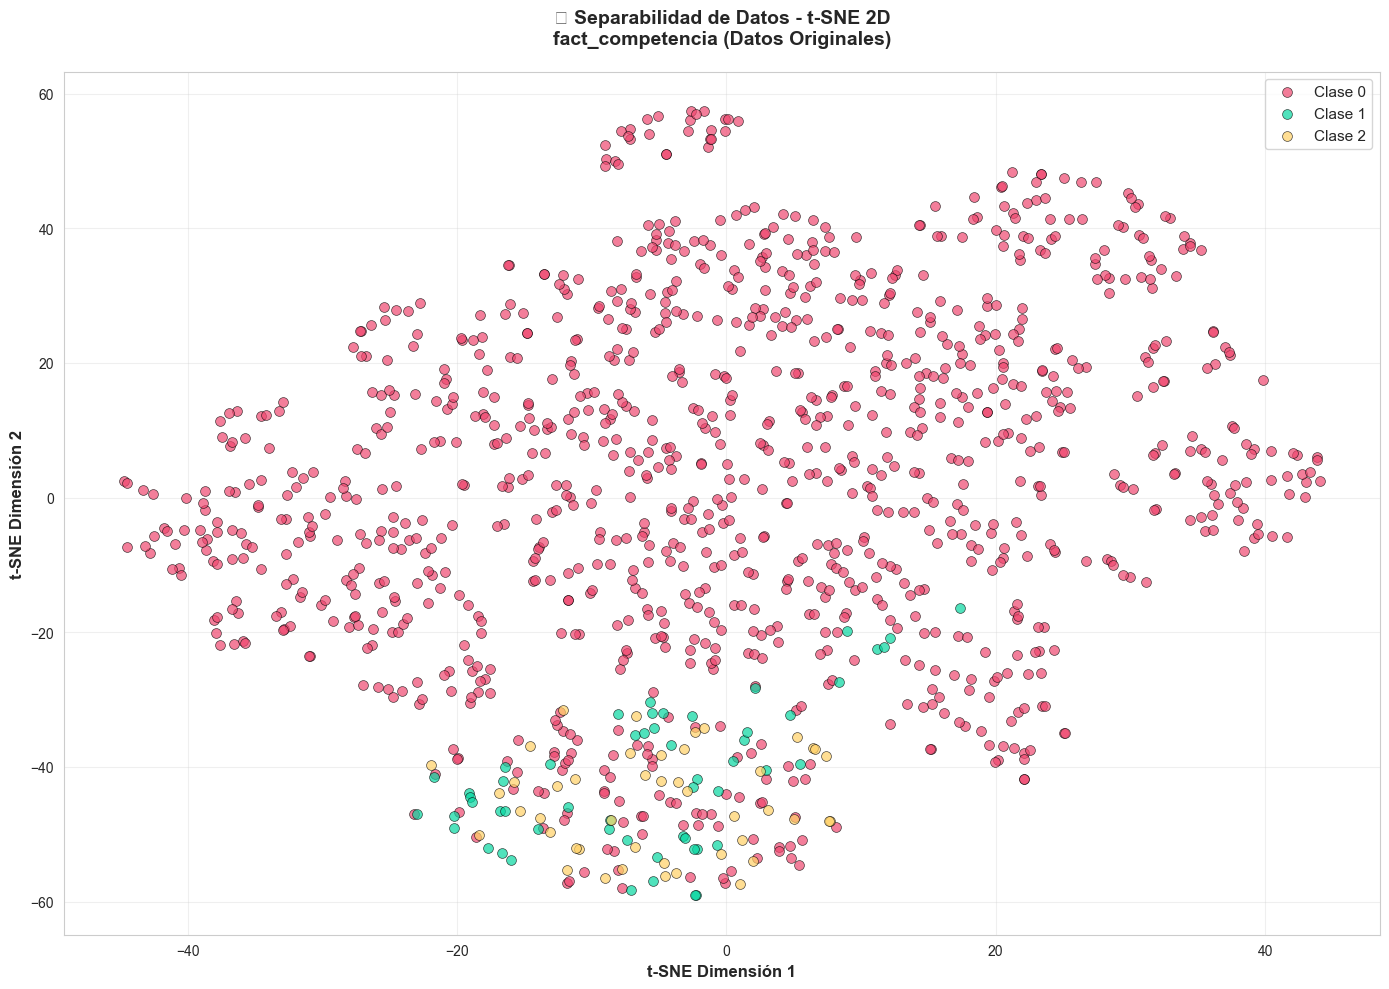

✅ Gráfico t-SNE guardado en outputs/02_tsne_separabilidad.png


In [18]:
# Visualizar t-SNE coloreado por clase
fig, ax = plt.subplots(figsize=(14, 10))

colors = ['#EF476F', '#06D6A0', '#FFD166']  # Rojo, Verde, Amarillo
class_names = ['Clase 0', 'Clase 1', 'Clase 2']

for i, (class_val, color, name) in enumerate(zip(sorted(y.unique()), colors, class_names)):
    mask = y == class_val
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
              c=color, label=name, s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

ax.set_xlabel('t-SNE Dimensión 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimensión 2', fontsize=12, fontweight='bold')
ax.set_title('🎯 Separabilidad de Datos - t-SNE 2D\nfact_competencia (Datos Originales)', 
            fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/02_tsne_separabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfico t-SNE guardado en outputs/02_tsne_separabilidad.png")

In [19]:
# Calcular métrica de separabilidad (Silhouette Score)
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

silhouette = silhouette_score(X_scaled, y)
davies_bouldin = davies_bouldin_score(X_scaled, y)
calinski = calinski_harabasz_score(X_scaled, y)

print("\n📊 MÉTRICAS DE SEPARABILIDAD:")
print(f"\nSilhouette Score: {silhouette:.4f}")
print("  → Rango: [-1, 1]")
print("  → > 0.5: Bien separado")
print("  → 0.3-0.5: Moderadamente separado")
print("  → < 0.3: Mal separado")
print(f"  ➜ RESULTADO: {'✅ BIEN' if silhouette > 0.5 else '⚠️ OK' if silhouette > 0.3 else '🔴 MALO'}")

print(f"\nDavies-Bouldin Index: {davies_bouldin:.4f}")
print("  → Menor es mejor")
print("  → < 1: Bien separado")
print(f"  ➜ RESULTADO: {'✅ BIEN' if davies_bouldin < 1 else '⚠️ OK'}")

print(f"\nCalinski-Harabasz Index: {calinski:.4f}")
print("  → Mayor es mejor")
print("  → > 100: Bien separado")


📊 MÉTRICAS DE SEPARABILIDAD:

Silhouette Score: 0.0328
  → Rango: [-1, 1]
  → > 0.5: Bien separado
  → 0.3-0.5: Moderadamente separado
  → < 0.3: Mal separado
  ➜ RESULTADO: 🔴 MALO

Davies-Bouldin Index: 5.5718
  → Menor es mejor
  → < 1: Bien separado
  ➜ RESULTADO: ⚠️ OK

Calinski-Harabasz Index: 16.1519
  → Mayor es mejor
  → > 100: Bien separado


## PASO 6: Recomendaciones de Reducción de Características

In [20]:
# Análisis de Componentes Principales (PCA) para entender varianza
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

# Encontrar cuántas componentes explican 95% de varianza
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
n_components_90 = np.argmax(cumsum_var >= 0.90) + 1

print("\n📈 ANÁLISIS PCA - VARIANZA EXPLICADA:")
print(f"\nTotal de features actuales: {X_scaled.shape[1]}")
print(f"Componentes para 90% varianza: {n_components_90}")
print(f"Componentes para 95% varianza: {n_components_95}")
print(f"\nReducción posible:")
print(f"  → De {X_scaled.shape[1]} a {n_components_95} features (95% varianza) = {(1 - n_components_95/X_scaled.shape[1])*100:.1f}% reducción")
print(f"  → De {X_scaled.shape[1]} a {n_components_90} features (90% varianza) = {(1 - n_components_90/X_scaled.shape[1])*100:.1f}% reducción")


📈 ANÁLISIS PCA - VARIANZA EXPLICADA:

Total de features actuales: 179
Componentes para 90% varianza: 54
Componentes para 95% varianza: 84

Reducción posible:
  → De 179 a 84 features (95% varianza) = 53.1% reducción
  → De 179 a 54 features (90% varianza) = 69.8% reducción


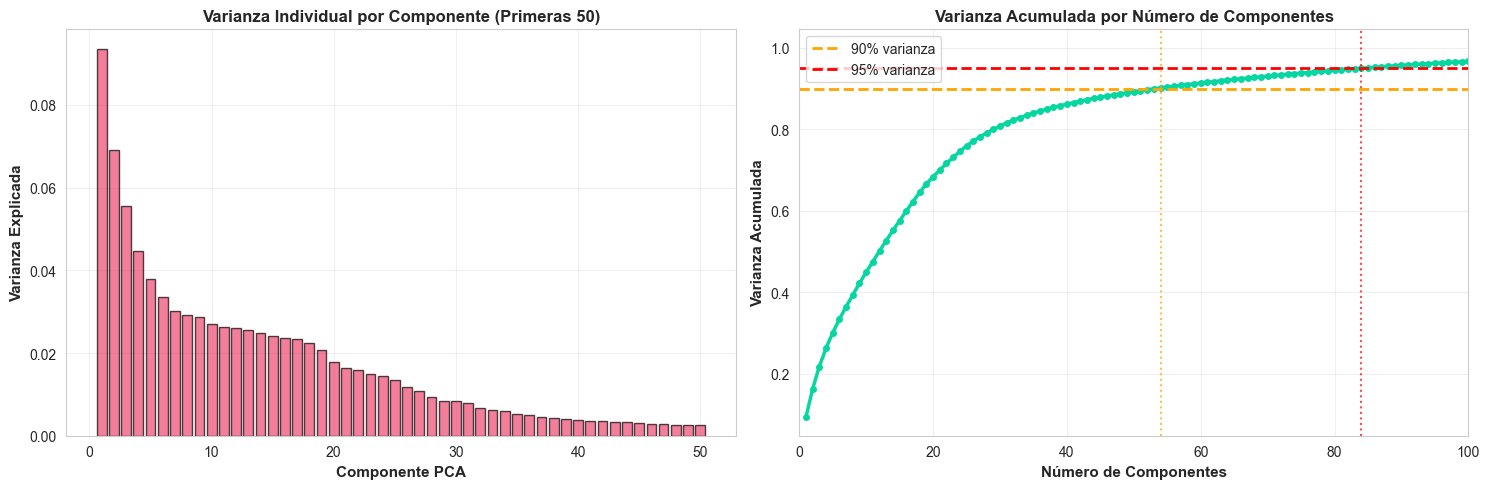

✅ Gráfico PCA guardado en outputs/03_pca_varianza.png


In [21]:
# Graficar varianza explicada por PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Varianza individual por componente
ax1.bar(range(1, min(51, len(pca.explained_variance_ratio_)+1)), 
        pca.explained_variance_ratio_[:50], 
        color='#EF476F', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Componente PCA', fontsize=11, fontweight='bold')
ax1.set_ylabel('Varianza Explicada', fontsize=11, fontweight='bold')
ax1.set_title('Varianza Individual por Componente (Primeras 50)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Varianza acumulada
ax2.plot(range(1, len(cumsum_var)+1), cumsum_var, 'o-', color='#06D6A0', linewidth=2.5, markersize=4)
ax2.axhline(0.90, color='orange', linestyle='--', linewidth=2, label='90% varianza')
ax2.axhline(0.95, color='red', linestyle='--', linewidth=2, label='95% varianza')
ax2.axvline(n_components_90, color='orange', linestyle=':', alpha=0.7)
ax2.axvline(n_components_95, color='red', linestyle=':', alpha=0.7)
ax2.set_xlabel('Número de Componentes', fontsize=11, fontweight='bold')
ax2.set_ylabel('Varianza Acumulada', fontsize=11, fontweight='bold')
ax2.set_title('Varianza Acumulada por Número de Componentes', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, min(100, len(cumsum_var)))

plt.tight_layout()
plt.savefig('outputs/03_pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Gráfico PCA guardado en outputs/03_pca_varianza.png")

In [22]:
# Recomendación final
print("\n" + "="*70)
print("📋 RECOMENDACIÓN FINAL DE REDUCCIÓN DE CARACTERÍSTICAS")
print("="*70)

print(f"\n📊 Estado Actual:")
print(f"   • Muestras: {X_scaled.shape[0]}")
print(f"   • Features: {X_scaled.shape[1]}")
print(f"   • Ratio muestras:features = 1:{X_scaled.shape[1]/X_scaled.shape[0]:.2f}")

print(f"\n🔴 PROBLEMAS DETECTADOS:")
if silhouette < 0.3:
    print(f"   ✗ Silhouette bajo ({silhouette:.4f}) → Clases NO bien separadas")
if len(highly_corr) > 10:
    print(f"   ✗ Muchas features correlacionadas ({len(highly_corr)}) → Redundancia")
if X_scaled.shape[1] > 50:
    print(f"   ✗ Demasiadas features ({X_scaled.shape[1]}) → Maldición de dimensionalidad")

print(f"\n✅ OPCIONES DE REDUCCIÓN:")
print(f"   Opción 1 (AGRESIVA): Usar SelectKBest con k=30")
print(f"      → De {X_scaled.shape[1]} a 30 features ({(1-30/X_scaled.shape[1])*100:.1f}% reducción)")
print(f"      → Riesgo: Perder información")

print(f"\n   Opción 2 (RECOMENDADA): Usar PCA con 95% varianza")
print(f"      → De {X_scaled.shape[1]} a {n_components_95} features ({(1-n_components_95/X_scaled.shape[1])*100:.1f}% reducción)")
print(f"      → Ventaja: Mantiene información, elimina ruido")

print(f"\n   Opción 3 (CONSERVADORA): Usar PCA con 98% varianza")
n_components_98 = np.argmax(cumsum_var >= 0.98) + 1
print(f"      → De {X_scaled.shape[1]} a {n_components_98} features ({(1-n_components_98/X_scaled.shape[1])*100:.1f}% reducción)")
print(f"      → Ventaja: Máxima precisión, menos reducción")

print(f"\n   Opción 4 (PASO A PASO): Eliminar features correlacionadas")
print(f"      → Identificar pares con correlación > 0.9 ({len(highly_corr)} pares)")
print(f"      → Mantener 1 de cada par, eliminar la otra")
print(f"      → Aproximadamente: {X_scaled.shape[1] - len(highly_corr)} features restantes")

print(f"\n" + "="*70)


📋 RECOMENDACIÓN FINAL DE REDUCCIÓN DE CARACTERÍSTICAS

📊 Estado Actual:
   • Muestras: 1200
   • Features: 179
   • Ratio muestras:features = 1:0.15

🔴 PROBLEMAS DETECTADOS:
   ✗ Silhouette bajo (0.0328) → Clases NO bien separadas
   ✗ Demasiadas features (179) → Maldición de dimensionalidad

✅ OPCIONES DE REDUCCIÓN:
   Opción 1 (AGRESIVA): Usar SelectKBest con k=30
      → De 179 a 30 features (83.2% reducción)
      → Riesgo: Perder información

   Opción 2 (RECOMENDADA): Usar PCA con 95% varianza
      → De 179 a 84 features (53.1% reducción)
      → Ventaja: Mantiene información, elimina ruido

   Opción 3 (CONSERVADORA): Usar PCA con 98% varianza
      → De 179 a 116 features (35.2% reducción)
      → Ventaja: Máxima precisión, menos reducción

   Opción 4 (PASO A PASO): Eliminar features correlacionadas
      → Identificar pares con correlación > 0.9 (7 pares)
      → Mantener 1 de cada par, eliminar la otra
      → Aproximadamente: 172 features restantes



## RESUMEN FINAL

In [23]:
# Crear tabla resumen
resumen = pd.DataFrame({
    'Métrica': [
        'Muestras',
        'Features Totales',
        'Ratio Muestras:Features',
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Features Correlacionadas (>0.9)',
        'PCA - Componentes para 95% var.',
        'PCA - Componentes para 90% var.',
    ],
    'Valor': [
        f"{X_scaled.shape[0]}",
        f"{X_scaled.shape[1]}",
        f"1:{X_scaled.shape[1]/X_scaled.shape[0]:.2f}",
        f"{silhouette:.4f}",
        f"{davies_bouldin:.4f}",
        f"{len(highly_corr)}",
        f"{n_components_95}",
        f"{n_components_90}",
    ],
    'Estado': [
        '✅',
        '⚠️ ALTO',
        '🔴 CRÍTICO',
        '🔴 Mal' if silhouette < 0.3 else '⚠️ OK',
        '✅' if davies_bouldin < 1 else '⚠️',
        '🔴 MUCHAS' if len(highly_corr) > 10 else '⚠️',
        '✅',
        '✅',
    ]
})

print("\n📊 TABLA RESUMEN:")
print(resumen.to_string(index=False))

# Guardar resumen
resumen.to_csv('outputs/00_resumen_analisis.csv', index=False)
print(f"\n✅ Resumen guardado en outputs/00_resumen_analisis.csv")


📊 TABLA RESUMEN:
                        Métrica  Valor    Estado
                       Muestras   1200         ✅
               Features Totales    179   ⚠️ ALTO
        Ratio Muestras:Features 1:0.15 🔴 CRÍTICO
               Silhouette Score 0.0328     🔴 Mal
           Davies-Bouldin Index 5.5718        ⚠️
Features Correlacionadas (>0.9)      7        ⚠️
PCA - Componentes para 95% var.     84         ✅
PCA - Componentes para 90% var.     54         ✅

✅ Resumen guardado en outputs/00_resumen_analisis.csv


In [24]:
# Exportar datos preprocesados para el Notebook 02
import numpy as np
import os
os.makedirs('outputs', exist_ok=True)
np.savez('outputs/01_processed_data.npz', X_scaled=X_scaled, y=y)
print("✅ Datos preprocesados (X_scaled, y) guardados exitosamente en outputs/01_processed_data.npz")

✅ Datos preprocesados (X_scaled, y) guardados exitosamente en outputs/01_processed_data.npz
